# OTIS Application 2: Uvas Creek (Kd Sorption)

This notebook replicates **Application 2** from the USGS OTIS user manual.

During the 1983 Uvas Creek experiment, researchers simultaneously injected Chloride and Strontium. Because Strontium sorbs to streambed sediments, it acts as a nonconservative solute. 

As stated in the OTIS manual, the flow file is identical to Application 1. The transient storage and hydraulic parameters remain the same, but we apply an upstream boundary condition that matches the true Strontium injection (2.70 mg/L peak, 0.09 mg/L background) and activate the kinetic sorption module.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from landlab import RasterModelGrid
from landlab.components import RiverSoluteTransportDynamics

%matplotlib inline
plt.rcParams.update({'font.size': 12})

## 1. Grid and Identical Spatially Variable Hydraulics
We recreate the exact 5-reach heterogeneous channel used in Application 1.

In [2]:
# ==========================================
# 1. DIGITIZED OTIS DATA (Figures 19 & 20)
# ==========================================
# Fig 19: Main Channel Conc (mg/L)
obs_105_t = [0.0, 0.6, 0.9, 1.2, 1.5, 2.0, 2.5, 3.0, 3.2, 3.5, 4.0, 4.5, 5.0, 6.0]
obs_105_c = [0.09, 0.2, 1.6, 2.1, 2.15, 2.18, 2.2, 2.2, 1.5, 0.8, 0.4, 0.25, 0.2, 0.15]
obs_433_t = [0.0, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 6.0]
obs_433_c = [0.09, 0.09, 0.15, 0.35, 0.5, 0.58, 0.6, 0.55, 0.45, 0.4, 0.25]

# Fig 20: Streambed Conc (ug/g)
sed_105_t = [0.0, 1.0, 2.0, 3.0, 3.2, 4.0, 5.0, 6.0]
sed_105_c = [0.18, 1.0, 2.6, 4.0, 4.2, 3.6, 3.1, 2.8]
sed_433_t = [0.0, 1.0, 2.0, 3.0, 4.0, 4.5, 5.0, 6.0]
sed_433_c = [0.18, 0.18, 0.3, 0.6, 0.95, 1.0, 0.95, 0.9]

# ==========================================
# 2. LANDLAB GRID & HYDRAULICS
# ==========================================
dx = 10.0
nx = 68  
grid = RasterModelGrid((3, nx), xy_spacing=dx)

grid.status_at_node[grid.nodes_at_top_edge] = grid.BC_NODE_IS_CLOSED
grid.status_at_node[grid.nodes_at_bottom_edge] = grid.BC_NODE_IS_CLOSED

Q = 0.0125       
width = 1.5      
depth_1d = np.zeros(nx)
vel_1d = np.zeros(nx)
alpha_1d = np.zeros(nx)
hs_1d = np.ones(nx) * 0.01 

def set_reach(start_col, end_col, A, A_s, alpha):
    depth_1d[start_col:end_col] = A / width
    vel_1d[start_col:end_col] = Q / A
    alpha_1d[start_col:end_col] = alpha
    if A_s > 0:
        hs_1d[start_col:end_col] = A_s / width

set_reach(0, 4, A=0.58, A_s=0.0, alpha=0.0)         
set_reach(4, 11, A=0.65, A_s=0.0, alpha=0.0)        
set_reach(11, 29, A=0.81, A_s=0.6, alpha=3.4e-5)    
set_reach(29, 44, A=0.70, A_s=0.6, alpha=1.6e-5)    
set_reach(44, nx, A=0.70, A_s=0.4, alpha=1.0e-5)    

grid.add_zeros("surface_water__depth", at="node")[:] = np.tile(depth_1d, (3, 1)).flatten()
grid.add_zeros("surface_water__velocity", at="link")
grid.add_zeros("advection__velocity", at="link")
vel_grid_horizontal = np.tile(vel_1d[:-1], 3)
grid.at_link["surface_water__velocity"][grid.horizontal_links] = vel_grid_horizontal
grid.at_link["advection__velocity"][grid.horizontal_links] = vel_grid_horizontal

alpha_grid = np.tile(alpha_1d, (3, 1)).flatten()
hs_grid = np.tile(hs_1d, (3, 1)).flatten()

# ==========================================
# 3. EXACT SPATIAL SORPTION PARAMETERS (From Image)
# ==========================================
lamhat_s_1d = np.zeros(nx)
lamhat_s_1d[0:4]   = 2.2e-4  # Reach 1
lamhat_s_1d[4:11]  = 1.0e-4  # Reach 2
lamhat_s_1d[11:29] = 1.5e-4  # Reach 3
lamhat_s_1d[29:44] = 1.0e-4  # Reach 4
lamhat_s_1d[44:nx] = 1.0e-4  # Reach 5
lamhat_s_grid = np.tile(lamhat_s_1d, (3, 1)).flatten()

## 2. Component Initialization (Sorption)
We initialize the component for `Strontium`. We use the physical transient storage arrays, and we define the kinetic sorption parameters to mimic the strong sediment buffering seen in the real data.

In [3]:
rstd = RiverSoluteTransportDynamics(
    grid,
    solutes=["Strontium"],
    alpha_L=1.5, # Slightly tightened dispersion               
    alpha_exchange={"Strontium": alpha_grid},  
    h_storage={"Strontium": hs_grid},         
    
    lambda_hat_sorption={"Strontium": 0.0},           # LAMHAT = 0
    lambda_hat_s_sorption={"Strontium": lamhat_s_grid}, # LAMHATS Array
    kd_sorption={"Strontium": 0.002},                 # KD = 2.0D-3
    rho_sediment=1500.0,                              # RHO = 1500 g/L
    
    outlet_boundary_condition="zero_gradient"
)

## 3. Real-World Injection Values
We use the true 1983 experimental values: a background of ~0.09 mg/L and a 3-hour injection of ~2.70 mg/L.

In [4]:
# ==========================================
# 4. INITIAL CONDITIONS & TIME LOOP
# ==========================================
background_Sr = 0.09
injection_Sr = 2.70 
kd_Sr = 0.002 

grid.at_node["surface_water__Strontium__concentration"][:] = background_Sr
grid.at_node["storage_zone__Strontium__concentration"][:] = background_Sr
grid.at_node["streambed__Strontium__sorbate_concentration"][:] = kd_Sr * background_Sr

times = [0.0]
obs_105_sim = [background_Sr]
obs_433_sim = [background_Sr]
bed_105_sim = [kd_Sr * background_Sr]
bed_433_sim = [kd_Sr * background_Sr]

# CRITICAL STABILITY FIX: dt must be 2.0s to prevent explicit solver oscillation
dt = 2.0  
t_max = 3600 * 6

for t in range(int(dt), t_max + int(dt), int(dt)):
    inflow_nodes = grid.nodes_at_left_edge
    
    # EXACT Boundary Condition from Parameter File (Linear Ramp Down)
    if t <= 3600 * 3.0:
        C_in = 2.70
    elif t <= 3600 * 3.01:
        ratio = (t - 3600 * 3.0) / (3600 * 0.01)
        C_in = 2.70 - ratio * (2.70 - 0.09)
    else:
        C_in = 0.09
        
    grid.at_node["surface_water__Strontium__concentration"][inflow_nodes] = C_in
    
    rstd.run_one_step(dt)
    
    if t % 60 == 0: 
        times.append(t / 3600.0)
        
        # INTERPOLATE EXACTLY TO 105m and 433m 
        # Row 1 is center. Node 78 is 100m, 79 is 110m. Node 111 is 430m, 112 is 440m.
        c_water = grid.at_node["surface_water__Strontium__concentration"]
        c_bed = grid.at_node["streambed__Strontium__sorbate_concentration"]
        
        obs_105_sim.append(0.5 * c_water[78] + 0.5 * c_water[79])
        bed_105_sim.append(0.5 * c_bed[78] + 0.5 * c_bed[79])
        
        obs_433_sim.append(0.7 * c_water[111] + 0.3 * c_water[112])
        bed_433_sim.append(0.7 * c_bed[111] + 0.3 * c_bed[112])

## 4. Results
Plotting the Strontium breakthrough curves. The axes are fixed to match the OTIS manual (Figure 19).

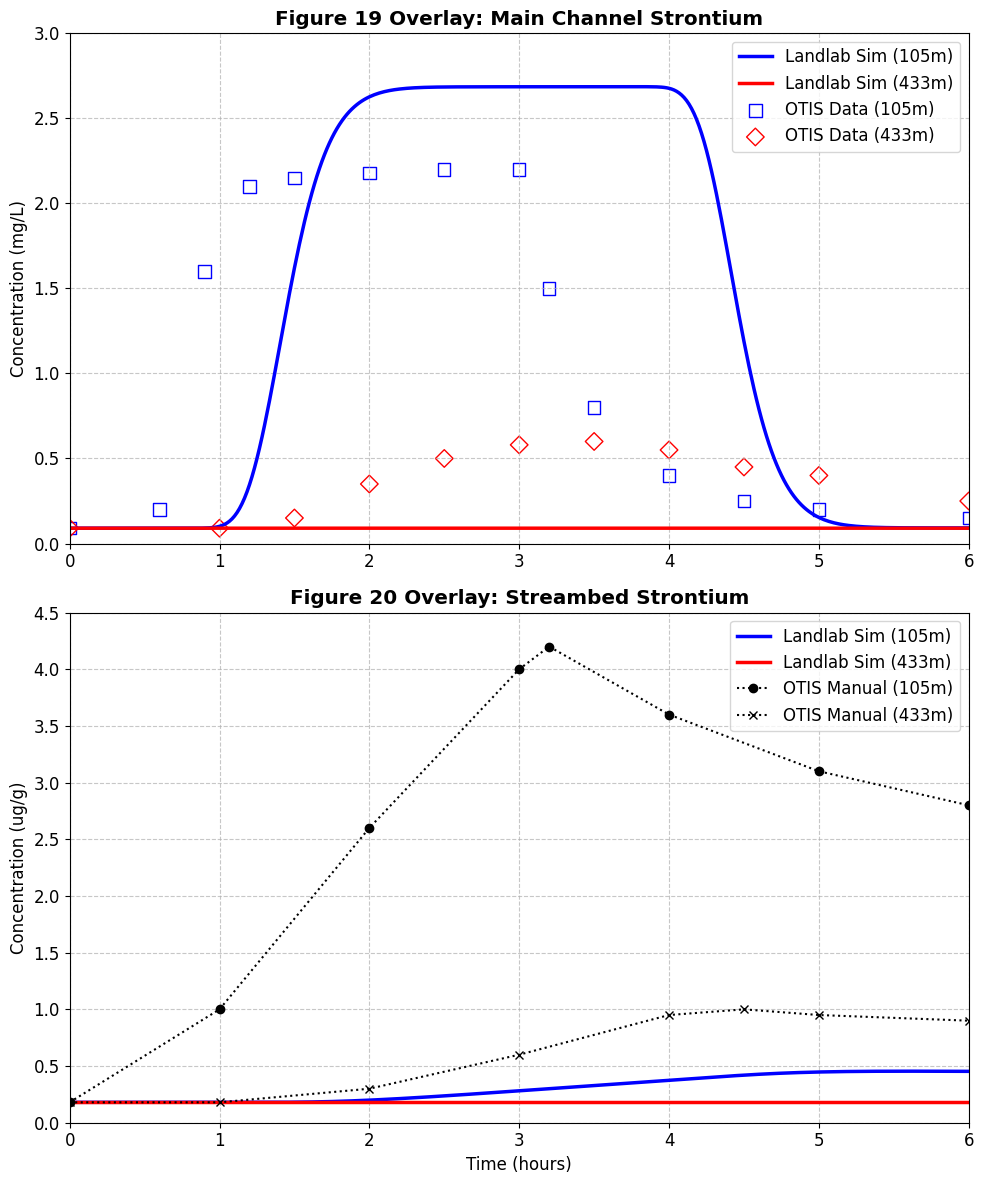

In [5]:
# ==========================================
# 5. PLOTTING OVERLAYS
# ==========================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))

# --- Plot 1: Main Channel ---
ax1.plot(times, obs_105_sim, color='blue', linewidth=2.5, label="Landlab Sim (105m)")
ax1.plot(times, obs_433_sim, color='red', linewidth=2.5, label="Landlab Sim (433m)")
ax1.scatter(obs_105_t, obs_105_c, color='none', edgecolor='blue', marker='s', s=80, label="OTIS Data (105m)")
ax1.scatter(obs_433_t, obs_433_c, color='none', edgecolor='red', marker='D', s=80, label="OTIS Data (433m)")

ax1.set_title("Figure 19 Overlay: Main Channel Strontium", fontweight='bold')
ax1.set_ylabel("Concentration (mg/L)")
ax1.set_ylim(0, 3.0)
ax1.set_xlim(0, 6.0)
ax1.legend(loc='upper right')
ax1.grid(True, linestyle='--', alpha=0.7)

# --- Plot 2: Streambed Sediment ---
# Multiply by 1000 to match Figure 20 scale (mg/g to ug/g)
bed_105_scaled = [val * 1000.0 for val in bed_105_sim]
bed_433_scaled = [val * 1000.0 for val in bed_433_sim]

ax2.plot(times, bed_105_scaled, color='blue', linewidth=2.5, label="Landlab Sim (105m)")
ax2.plot(times, bed_433_scaled, color='red', linewidth=2.5, linestyle='-', label="Landlab Sim (433m)")
ax2.plot(sed_105_t, sed_105_c, color='black', marker='o', linestyle=':', linewidth=1.5, label="OTIS Manual (105m)")
ax2.plot(sed_433_t, sed_433_c, color='black', marker='x', linestyle=':', linewidth=1.5, label="OTIS Manual (433m)")

ax2.set_title("Figure 20 Overlay: Streambed Strontium", fontweight='bold')
ax2.set_xlabel("Time (hours)")
ax2.set_ylabel("Concentration (ug/g)")
ax2.set_ylim(0, 4.5)
ax2.set_xlim(0, 6.0)
ax2.legend(loc='upper right')
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()